<a href="https://colab.research.google.com/github/samarreguigui/AI_Ethik/blob/main/01_media_bias_dataset_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Read the data from google drive
from google.colab import drive
import openai
import pandas as pd
import time
import re
import os
from google.colab import drive
from urllib.parse import urlparse
#import tldextract
from tqdm import tqdm
import matplotlib.pyplot as plt


In [65]:
client = openai.OpenAI(api_key=)


In [10]:
drive.mount('/content/drive')
file_path_dolmino_left_right = "/content/drive/MyDrive/Master thesis/left_right_only/dolmino_classified.csv"
file_path_dolmino_neutral = "/content/drive/MyDrive/Master thesis/neutral/dolmino_classified.csv"
file_path_dolma_left_right = "/content/drive/MyDrive/Master thesis/left_right_only/dolma_classified.csv"
file_path_dolma_neutral = "/content/drive/MyDrive/Master thesis/neutral/dolma_classified.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#***How does data filtering change political bias***

In [11]:
dolmino_neutral = pd.read_csv(file_path_dolmino_neutral)
dolmino_left_right=pd.read_csv(file_path_dolmino_left_right)
dolma_neutral = pd.read_csv(file_path_dolma_neutral)
dolma_left_right=pd.read_csv(file_path_dolma_left_right)

(17434, 12)

In [12]:
print(dolmino_neutral.shape)
print(dolma_neutral.shape)
print(dolmino_left_right.shape)
print(dolma_left_right.shape)

(165515, 9)
(282290, 12)
(13911, 9)
(17434, 12)


In [13]:
dolma_total = len(dolma_left_right) + len(dolma_neutral)
dolmino_total = len(dolmino_left_right) + len(dolmino_neutral)

print("Dolma total:", dolma_total)
print("Dolmino total:", dolmino_total)

Dolma total: 299724
Dolmino total: 179426


In [18]:
dolmino_left_right.shape[0]

13911

In [19]:
#Percentage of left-right data comparing in the sample
dolma_political_ratio = (dolma_left_right.shape[0] / dolma_total)*100
dolmino_political_ratio = (dolmino_left_right.shape[0] / dolmino_total)*100

print("Dolma political %:", dolma_political_ratio)
print("Dolmino political %:", dolmino_political_ratio)

Dolma political %: 5.816684683241916
Dolmino political %: 7.75305697056168


Even though Dolmino is a filtered version of Dolma, the share of political content increases.
Because filtering removed more neutral content than political content.

This suggests:

The filtering process does not remove political text proportionally; instead, it disproportionately removes non-political material.

In [21]:
political_retention = (dolmino_left_right.shape[0] / dolma_left_right.shape[0])*100
neutral_retention = (dolmino_neutral.shape[0] / dolma_neutral.shape[0])*100

print("Political retention:", political_retention)
print("Neutral retention:", neutral_retention)

Political retention: 79.79235975679705
Neutral retention: 58.632966098692826


In [25]:
#Increase for political share data in the filtered Dolmino data

absolute_increase= dolmino_political_ratio- dolma_political_ratio
relative_increase = (
    ( absolute_increase)
    / dolma_political_ratio
) * 100

print(relative_increase)

33.28996486432425


The share of political documents increases from 5.82% in Dolma to 7.75% in Dolmino, representing a relative increase of approximately 33%. This indicates that filtering removes neutral content more aggressively than political content, thereby increasing the relative presence of political material in the filtered dataset.

In [26]:
dolma_political = dolma_left_right.shape[0]
dolma_neutral = dolma_neutral.shape[0]

dolmino_political = dolmino_left_right.shape[0]
dolmino_neutral = dolmino_neutral.shape[0]

dolma_total = dolma_political + dolma_neutral
dolmino_total = dolmino_political + dolmino_neutral

dolma_political_pct = dolma_political / dolma_total * 100
dolma_neutral_pct = dolma_neutral / dolma_total * 100

dolmino_political_pct = dolmino_political / dolmino_total * 100
dolmino_neutral_pct = dolmino_neutral / dolmino_total * 100

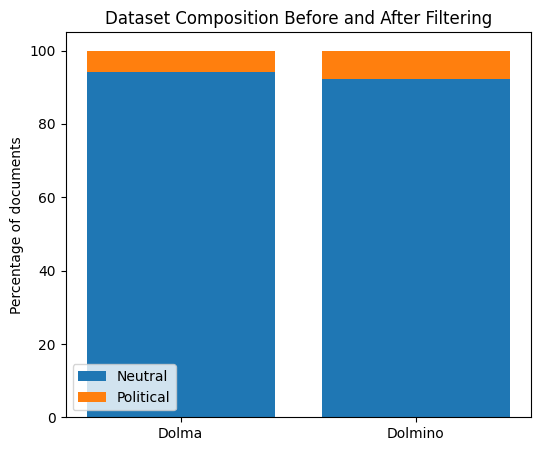

In [28]:
import matplotlib.pyplot as plt

labels = ["Dolma", "Dolmino"]

political = [dolma_political_pct, dolmino_political_pct]
neutral = [dolma_neutral_pct, dolmino_neutral_pct]

plt.figure(figsize=(6,5))

plt.bar(labels, neutral, label="Neutral")
plt.bar(labels, political, bottom=neutral, label="Political")

plt.ylabel("Percentage of documents")
plt.title("Dataset Composition Before and After Filtering")
plt.legend()

plt.show()

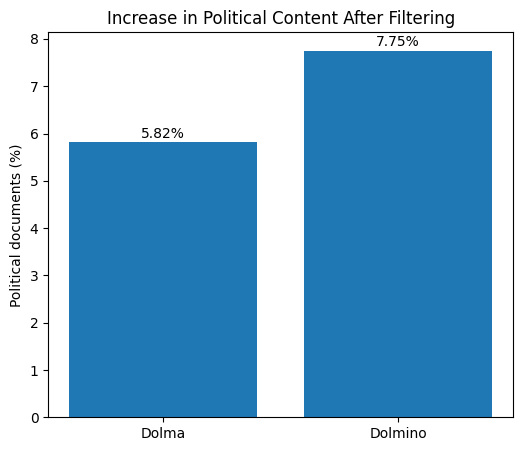

In [29]:

labels = ["Dolma", "Dolmino"]
political_pct = [dolma_political_pct, dolmino_political_pct]

plt.figure(figsize=(6,5))

plt.bar(labels, political_pct)

plt.ylabel("Political documents (%)")
plt.title("Increase in Political Content After Filtering")

# annotate values
for i, v in enumerate(political_pct):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center')

plt.show()

Does quality filtering in OLMo reduce political noise, or does it selectively preserve certain ideological styles and source types?

Does filtering change the ideological balance?

maybe right content is removed more
maybe left content is preserved more

In [37]:
dolma_dist = dolma_left_right["llama_label"].value_counts(normalize=True) * 100

In [36]:
dolmino_dist = dolmino_left_right["llama_label"].value_counts(normalize=True) * 100

In [38]:
#Relative changes
relative_change = (dolmino_dist - dolma_dist) / dolma_dist * 100
print(relative_change)

llama_label
left     3.248827
right   -8.947566
Name: proportion, dtype: float64


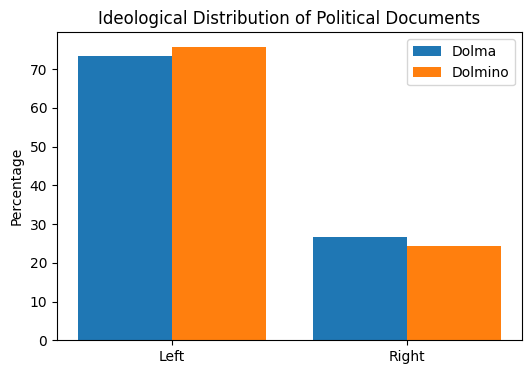

In [39]:
labels = ["Left", "Right"]

dolma_vals = [dolma_dist["left"], dolma_dist["right"]]
dolmino_vals = [dolmino_dist["left"], dolmino_dist["right"]]

x = range(len(labels))

plt.figure(figsize=(6,4))

plt.bar(x, dolma_vals, width=0.4, label="Dolma")
plt.bar([i+0.4 for i in x], dolmino_vals, width=0.4, label="Dolmino")

plt.xticks([i+0.2 for i in x], labels)
plt.ylabel("Percentage")
plt.title("Ideological Distribution of Political Documents")
plt.legend()

plt.show()

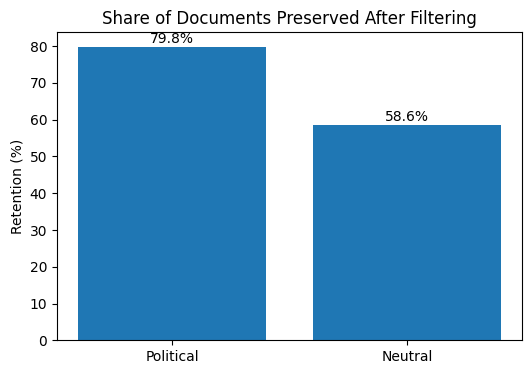

In [41]:
#How much of the original data survives the filtering step (Dolma → Dolmino).
labels = ["Political", "Neutral"]
values = [political_retention, neutral_retention]

plt.figure(figsize=(6,4))

plt.bar(labels, values)

plt.ylabel("Retention (%)")
plt.title("Share of Documents Preserved After Filtering")
for i,v in enumerate(values):
    plt.text(i, v+1, f"{v:.1f}%", ha="center")

plt.show()

The share of left-leaning documents increases from 73.36% in Dolma to 75.75% in Dolmino, representing a relative increase of approximately 3.25%, while the share of right-leaning documents decreases by 8.95%. This indicates that filtering slightly amplifies the existing ideological imbalance in the dataset and made it more left.

# ***Filtering Media Type***

In this study, media refers to online sources that publish political information, commentary, or opinion intended for a public audience. This includes traditional news outlets as well as digital political blogs and opinion websites.

In [90]:
#Check Basic
df.shape
df.columns
df['llama_label'].value_counts()

,count
llama_label,
left,10537
right,3374


In [123]:
df['llama_label'].value_counts(normalize=True)

,proportion
llama_label,
left,0.757458
right,0.242542


**Filter Media Data**

--> The dataset contains 13,911 documents labeled according to political ideology. The distribution is imbalanced, with 75.7% of documents classified as left-leaning and 24.3% classified as right-leaning. This imbalance indicates a potential ideological skew in the underlying media sources.

In [135]:
def classify_media_classic(domain):

    if pd.isna(domain):
        return "NONMEDIA"

    domain = str(domain).lower()

    nonmedia_keywords = [
        "wordpress","blogspot","medium","substack",
        "reddit","facebook","instagram","twitter","youtube",
        "amazon","ebay","shop","store","wikipedia"
    ]

    media_keywords = [
        "news","times","post","journal","guardian",
        "cnn","bbc","reuters","politico","economist","dw"
    ]

    if any(k in domain for k in nonmedia_keywords):
        return "NONMEDIA"

    if any(k in domain for k in media_keywords):
        return "MEDIA"

    return "UNKNOWN"

In [127]:
df_filtered = classify_media_classic(df)


Total rows before filtering: 100
Excluded rows: 15
Remaining rows: 85


In [144]:
def classify_media_gpt4o(domain: str):
    """GPT-4o-mini: Is this a legitimate news/media domain?"""
    prompt = f"""Is this a media Platform ? Return ONLY: MEDIA or NONMEDIA.

Media is broad; Non-Media is targeted and local. Cost: Media is generally high; Non-Media is more moderate and scalable. Impact Duration: Media has a long-term impact (awareness); Non-Media often has a momentary impact (immediate sales, events).

Domain: {domain}
Verdict:""".strip()


    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            max_tokens=5
        )

        llm_raw = response.choices[0].message.content.strip().upper()

        if llm_raw == "MEDIA":
            return "MEDIA"
        elif llm_raw == "NONMEDIA":
            return "NONMEDIA"
        else:
            return "NONMEDIA"

    except Exception:
        return "NONMEDIA"


In [114]:
# Helper to extract clean domain
def extract_domain(url: str) -> str:
    if pd.isna(url) or not str(url).strip():
        return ""
    netloc = urlparse(str(url)).netloc.lower().strip()
    return netloc.replace("www.", "")

In [136]:
def data_prep(df):

  # parse domain from URL
  df["domain"] = df["url"].apply(extract_domain)
  # classic classifier
  df["media_classic"] = df["domain"].apply(classify_media_classic)

  # GPT classifier
  tqdm.pandas()
  df["media_gpt4o"] = df["domain"].progress_apply(classify_media_gpt4o)

  return df

In [145]:
TEST_SIZE = 200
file_path = "/content/drive/MyDrive/Master thesis/left_right_only/dolmino_classified.csv"
df_full = pd.read_csv(file_path)
df = df_full.head(TEST_SIZE).copy() if TEST_SIZE > 0 else df_full.copy()

df_final = data_prep(df)


100%|██████████| 200/200 [01:34<00:00,  2.11it/s]


In [146]:
print(df_final['media_gpt4o'].value_counts())


media_gpt4o
NONMEDIA    142
MEDIA        58
Name: count, dtype: int64


In [147]:
df_final

,id,text,llama_label,url,provenance,original_length,content_type,publisher,lang_en,domain,media_classic,media_gpt4o
0,https://www.cochrane4senate.com/Changes--Votin...,﻿ CHRISTOPHER MARK COCHRANE - Changes: Voting ...,left,https://www.cochrane4senate.com/Changes--Votin...,dclm-0174.json.zst:84658,50439,application/http; msgtype=response,Common Crawl,0.956217,cochrane4senate.com,UNKNOWN,NONMEDIA
1,http://www.capitolhillblue.com/node/18173,Government wisdom in marriage\n\nHere are a fe...,left,http://www.capitolhillblue.com/node/18173,dclm-0090.json.zst:1060548,30199,application/http; msgtype=response,CommonCrawl,0.951662,capitolhillblue.com,UNKNOWN,MEDIA
2,https://iamyouasheisme.wordpress.com/2011/09/1...,Harvard – Bought and Paid For\n\nInside Job is...,left,https://iamyouasheisme.wordpress.com/2011/09/1...,dclm-0143.json.zst:168043,86231,application/http; msgtype=response,CommonCrawl,0.953221,iamyouasheisme.wordpress.com,NONMEDIA,NONMEDIA
3,https://graduateway.com/analysis-of-mississipp...,Analysis of Mississippi Burning\n\nAnalysis an...,left,https://graduateway.com/analysis-of-mississipp...,dclm-0395.json.zst:704495,22594,application/http; msgtype=response,Common Crawl,0.975842,graduateway.com,UNKNOWN,NONMEDIA
4,http://counterfem2.blogspot.com/2015/04/again-...,"Tuesday, April 14, 2015\n\nAgain: What is this...",right,http://counterfem2.blogspot.com/2015/04/again-...,dclm-0363.json.zst:789675,56311,application/http; msgtype=response,Common Crawl,0.953146,counterfem2.blogspot.com,NONMEDIA,NONMEDIA
...,...,...,...,...,...,...,...,...,...,...,...,...
195,http://www.libertarianism.org/publications/ess...,"\n\nJul 8, 2010\n\nThe Case for Ordered Libert...",left,http://www.libertarianism.org/publications/ess...,dclm-0183.json.zst:426357,34890,application/http; msgtype=response,CommonCrawl,0.959762,libertarianism.org,UNKNOWN,NONMEDIA
196,https://lifeword.org/blog/resurrection-the-bur...,"Apr 20, 2019 07:00am\nResurrection: The Burden...",right,https://lifeword.org/blog/resurrection-the-bur...,dclm-0256.json.zst:759532,130144,application/http; msgtype=response,Common Crawl,0.975060,lifeword.org,UNKNOWN,NONMEDIA
197,http://www.theatlantic.com/technology/archive/...,The Electronic Communications Privacy Act of 1...,left,http://www.theatlantic.com/technology/archive/...,dclm-0352.json.zst:40988,110284,application/http; msgtype=response,CommonCrawl,0.964478,theatlantic.com,UNKNOWN,MEDIA
198,https://www.mywaste.ie/news/climate-change-yes...,"Climate change: Yes, your individual action do...",left,https://www.mywaste.ie/news/climate-change-yes...,dclm-0187.json.zst:466624,64121,application/http; msgtype=response,Common Crawl,0.948930,mywaste.ie,UNKNOWN,NONMEDIA


# ***Topic-specific evaluative framing***

In addition to source-level labels such as political ideology, regional origin, and credibility, the analysis incorporates topic-specific sentiment as a linguistic indicator of evaluative framing, allowing the thesis to examine not only whether bias is present, but also how it is expressed across topics.

#**Add Source-Credibility Using GPT 4o mini**


In [38]:
# Drive to save the result
drive.mount('/content/drive')
file_path_credibility = "/content/drive/MyDrive/Master thesis/Credibility domain"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
#Use GPT 4- mini to categorize the domainns to source credibilities
def classify_domain_gpt4o_mini(domain: str):

    prompt = f"""Source credibility classification. Return ONLY one word: HIGH, MEDIUM, LOW, or UNKNOWN.

HIGH = Major established news (nytimes.com, bbc.com, reuters.com, theguardian.com)
MEDIUM = Legit mid-tier/opinion (huffingtonpost.com, salon.com, townhall.com)
LOW = Fringe/conspiracy (conservapedia.com, icr.org, breitbart.com)
UNKNOWN = Obscure/not news (weownthecompanies.com)

Domain: {domain}
Source credibility:"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            max_tokens=5
        )
        llm_raw_answer = response.choices[0].message.content

        # Extract credibility from raw answer (first word)
        first_word = llm_raw_answer.strip().split()[0].upper() if llm_raw_answer.strip() else ''

        # Standardize credibility from first word
        if first_word in {'HIGH', 'MEDIUM', 'LOW', 'UNKNOWN'}:
            credibility = first_word
        else:
            credibility = '-1'

        return credibility, llm_raw_answer  # Raw GPT answer + extracted credibility

    except Exception as e:
        return '-1', f"ERROR: {str(e)}"


In [53]:
# Build the source domane credibility table

def process_domain_chunk(chunk_domains: list, chunk_id: int, file_path: str):
    """Process one chunk of domains, save results, append to master table"""
    print(f"\n🔄 Processing chunk {chunk_id} ({len(chunk_domains)} domains)...")

    results = []
    for i, domain in enumerate(chunk_domains):
        credibility, llm_raw = classify_domain_gpt4o_mini(domain)
        results.append({
            'domain': domain,
            'source_credibility': credibility,
            'llm_answer': llm_raw
        })
        print(f"  {i+1}/{len(chunk_domains)}: {domain} → {credibility}")
        time.sleep(0.2)  # Rate limit

    # Save chunk results
    chunk_df = pd.DataFrame(results)
    chunk_df.to_csv(f"{file_path}/chunk_{chunk_id:03d}.csv", index=False)

   # Load previous master table (if exists) and append
    master_file = f"{file_path}/domain_credibility_master.csv"
    if os.path.exists(master_file):
        master_df = pd.read_csv(master_file)
        updated_df = pd.concat([master_df, chunk_df], ignore_index=True)
    else:
        updated_df = chunk_df
    # Save updated master table
    updated_df.to_csv(master_file, index=False)
    print(f"✅ Chunk {chunk_id} saved. Master table now has {len(updated_df)} domains")

    return updated_df

In [54]:
def process_all_domains(df, file_path_credibility, chunk_size=3):
    """
    Process all unique domains in configurable chunk sizes and save domain table only

    Args:
        df: your main dataframe with 'domain' column
        file_path_credibility: save path
        chunk_size: domains per chunk (default 50)
    """
    # Get unique domains only and process it in chunks
    print(f"Starting domain credibility classification ({len(df['domain'].unique())} domains, chunk_size={chunk_size})")
    all_domains = df['domain'].unique().tolist()  # All unique domains

    # Split into chunks
    chunk_size = max(1, chunk_size)
    chunks = [all_domains[i:i+chunk_size] for i in range(0, len(all_domains), chunk_size)]
    print(f"Split into {len(chunks)} chunks (~{chunk_size} domains each)")

    # Create directory
    os.makedirs(file_path_credibility, exist_ok=True)

    # Process chunks one by one
    master_results = None
    for chunk_id, chunk_domains in enumerate(chunks, 1):
        master_results = process_domain_chunk(chunk_domains, chunk_id, file_path_credibility)
        print(f"Saved chunk {chunk_id}/{len(chunks)}")

    print(f"\n✅ ALL SAVED: {file_path_credibility}/domain_credibility_master.csv")
    return master_results


# **Add Region using gpt4-mini**

In [68]:
def classify_region_gpt4o_mini(domain: str):
    """Classify domain region ONLY - US/UK/EU/Other"""
    prompt = f"""Classify this news/media domain's primary country/region.
Return ONLY one word: US, UK, EU, or Other.


Domain: {domain}
Region:"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            max_tokens=5
        )

        # Raw LLM answer (unmodified)
        llm_raw_region = response.choices[0].message.content

        # Extract first word for standardized region
        first_word = llm_raw_region.strip().split()[0].upper() if llm_raw_region.strip() else ''

        # Standardize
        if first_word in {'US', 'UK', 'EU', 'OTHER'}:
            region = first_word
        else:
            region = '-1'

        return region, llm_raw_region  # Standardized + raw GPT answer

    except Exception as e:
        return '-1', f"ERROR: {str(e)}"


In [86]:
df['domain'].value_counts().head(10)

,count
domain,
www.theguardian.com,63
www.huffingtonpost.com,51
www.theatlantic.com,48
www.icr.org,39
www.conservapedia.com,39
townhall.com,33
www.thenation.com,29
mises.org,27
www.studymode.com,26


#**Main**

In [ ]:

# 1. FILTER UNIQUE DOMAINS FIRST
unique_df = df[['domain']].drop_duplicates().reset_index(drop=True)
print(f"Original df: {len(df)} rows → Unique domains: {len(unique_df)} domains")
# 2. NOW process only unique domains in Batches
master_df = process_all_domains(unique_df, file_path_credibility, chunk_size=200)
# 3. join the domaine master_df with the df
